In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import DiadFit as pf
pf.__version__

'1.0.11'

## Lets load in all the power series. 

In [16]:


df= pd.read_excel(r'C:\Users\penny\Box\Berkeley_new\Raman\Raman technical paper\Supporting_Info\Supporting_information_Draft1.xlsx',
                          sheet_name='power_series')

df_16=df.loc[df['filename'].str.contains('FG04-A11-16')]
df_9=df.loc[df['filename'].str.contains('FG04-A11-9')]
df_21=df.loc[df['filename'].str.contains('Ulu')]
# Filt out 49 mW with a big cosmic ray so bad peak fit
df_21=df_21.loc[df_21['power (mW)']<49]

In [17]:
df_21

,Unnamed: 0,filename,Density g/cm3,σ Density g/cm3,σ Density g/cm3 (from Ne+peakfit),σ Density g/cm3 (from densimeter),Corrected_Splitting,Corrected_Splitting_σ,Corrected_Splitting_σ_Ne,Corrected_Splitting_σ_peak_fit,...,Peak_Cent_Carb,Peak_Area_Carb,Peak_Height_Carb,Model_name_y,Carb_Diad_Ratio,SO2_Diad_Ratio,SO2_mol_ratio,Model_name,focus_testing,offset
0,0,Ulu_8mw,0.016672,0.009801,0.008980,0.003929,102.792332,0.022662,0.000367,0.022710,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Ulu_15mw,0.019705,0.006522,0.005214,0.003918,102.799985,0.013159,0.000368,0.013183,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Ulu_20mw,0.014709,0.005588,0.003968,0.003936,102.787377,0.010013,0.000369,0.010029,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Ulu_25mw,0.014820,0.005075,0.003204,0.003935,102.787656,0.008087,0.000370,0.008096,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Ulu_30mw,0.006000,0.005040,0.003106,0.003969,102.765399,0.007838,0.000372,0.007847,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,Ulu_40mw,0.012477,0.004609,0.002384,0.003944,102.781744,0.006017,0.000377,0.006019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7,Ulu_40mw_down,0.011545,0.004787,0.002708,0.003947,102.779391,0.006834,0.000386,0.006839,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,8,Ulu_30mw_down,0.016615,0.004776,0.002716,0.003929,102.792188,0.006854,0.000391,0.006859,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,9,Ulu_20mw_down,0.008247,0.005325,0.003559,0.003960,102.771068,0.008983,0.000396,0.008995,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,10,Ulu_15mw_down,0.012926,0.005914,0.004409,0.003942,102.782878,0.011127,0.000402,0.011145,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
df_21=df_21.loc[df_21['σ Density g/cm3']>0]

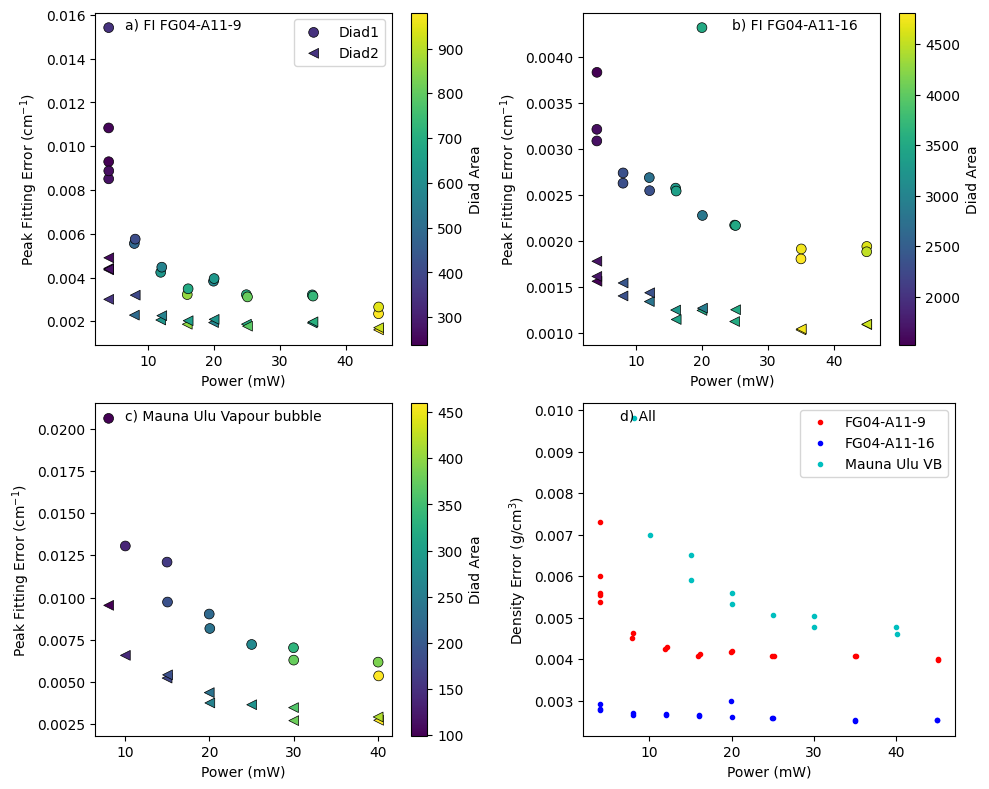

In [25]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize = (10,8))

s=ax1.scatter(x=df_9['power (mW)'],
          y=df_9['Diad1_cent_err'], marker='o', s=50, edgecolors='k', linewidths=0.5,
            c=df_9['Diad1_Voigt_Area'], cmap='viridis', label='Diad1')

s=ax1.scatter(x=df_9['power (mW)'],
          y=df_9['Diad2_cent_err'], marker='<', s=50, edgecolors='k', linewidths=0.5,
            c=df_9['Diad2_Voigt_Area'], cmap='viridis',  label='Diad2')
fig.colorbar(s, ax=ax1, label='Diad Area')
ax1.set_xlabel('Power (mW)')
ax1.set_ylabel('Peak Fitting Error (cm$^{-1}$)')

ax1.annotate("a) FI FG04-A11-9 ", xy=(0.1, 0.95), xycoords="axes fraction", fontsize=10)
ax1.legend()

##########################
s=ax2.scatter(x=df_16['power (mW)'],
          y=df_16['Diad1_cent_err'], marker='o', s=50, edgecolors='k', linewidths=0.5,
            c=df_16['Diad1_Voigt_Area'], cmap='viridis')

s=ax2.scatter(x=df_16['power (mW)'],
          y=df_16['Diad2_cent_err'], marker='<', s=50, edgecolors='k', linewidths=0.5,
            c=df_16['Diad2_Voigt_Area'], cmap='viridis')
fig.colorbar(s, ax=ax2, label='Diad Area')
ax2.set_xlabel('Power (mW)')
ax2.set_ylabel('Peak Fitting Error (cm$^{-1}$)')

ax2.annotate("b) FI FG04-A11-16 ", xy=(0.5, 0.95), xycoords="axes fraction", fontsize=10)

##################3

s=ax3.scatter(x=df_21['power (mW)'],
          y=df_21['Diad1_cent_err'], marker='o', s=50, edgecolors='k', linewidths=0.5,
            c=df_21['Diad1_Voigt_Area'], cmap='viridis')

s=ax3.scatter(x=df_21['power (mW)'],
          y=df_21['Diad2_cent_err'], marker='<', s=50, edgecolors='k', linewidths=0.5,
            c=df_21['Diad2_Voigt_Area'], cmap='viridis')
fig.colorbar(s, ax=ax3, label='Diad Area')
ax3.set_xlabel('Power (mW)')
ax3.set_ylabel('Peak Fitting Error (cm$^{-1}$)')

ax3.annotate("c) Mauna Ulu Vapour bubble ", xy=(0.1, 0.95), xycoords="axes fraction", fontsize=10)

## Lets show them all for context

# ax4.plot(df_9['power (mW)'], 100*df_9['σ Density g/cm3']/df_9['Density g/cm3'].iloc[0], '.r')
# ax4.plot(df_21['power (mW)'], 100*df_21['σ Density g/cm3']/df_21['Density g/cm3'].iloc[0], '.b')
# ax4.plot(df_16['power (mW)'], 100*df_16['σ Density g/cm3']/df_16['Density g/cm3'].iloc[0], '.c')

ax4.plot(df_9['power (mW)'],df_9['σ Density g/cm3'], '.r', label='FG04-A11-9')
ax4.plot(df_16['power (mW)'], df_16['σ Density g/cm3'], '.b', label='FG04-A11-16')
ax4.plot(df_21['power (mW)'], df_21['σ Density g/cm3'], '.c', label='Mauna Ulu VB')
ax4.legend()

ax4.annotate("d) All", xy=(0.1, 0.95), xycoords="axes fraction", fontsize=10)


fig.tight_layout()
ax4.set_xlabel('Power (mW)')
ax4.set_ylabel('Density Error (g/cm$^{3}$)')
fig.savefig('Errors_laser_power.png', dpi=200)

In [20]:
df_9

,Unnamed: 0,filename,Density g/cm3,σ Density g/cm3,σ Density g/cm3 (from Ne+peakfit),σ Density g/cm3 (from densimeter),Corrected_Splitting,Corrected_Splitting_σ,Corrected_Splitting_σ_Ne,Corrected_Splitting_σ_peak_fit,...,Peak_Cent_Carb,Peak_Area_Carb,Peak_Height_Carb,Model_name_y,Carb_Diad_Ratio,SO2_Diad_Ratio,SO2_mol_ratio,Model_name,focus_testing,offset
12,0,FG04-A11-9-4mW-1,0.120687,0.007298,0.006213,0.003829,103.054836,0.015681,0.000536,0.015707,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,1,FG04-A11-9-4mW-1re,0.114888,0.005584,0.004073,0.003820,103.040200,0.010279,0.000534,0.010288,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,2,FG04-A11-9-4mW-1re2,0.123675,0.006005,0.004621,0.003834,103.062377,0.011662,0.000533,0.011676,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,3,FG04-A11-9-8mW-1,0.116594,0.004505,0.002384,0.003822,103.044508,0.006016,0.000530,0.006006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,4,FG04-A11-9-12mW-1,0.109208,0.004249,0.001875,0.003813,103.025866,0.004731,0.000528,0.004712,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,5,FG04-A11-9-16mW-1,0.106470,0.004090,0.001486,0.003810,103.018956,0.003751,0.000526,0.003723,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,6,FG04-A11-9-20mW-1,0.114547,0.004185,0.001711,0.003820,103.039340,0.004319,0.000524,0.004297,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,7,FG04-A11-9-25mW-1,0.103404,0.004087,0.001485,0.003807,103.011219,0.003748,0.000524,0.003720,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,8,FG04-A11-9-35mW-1,0.104868,0.004091,0.001494,0.003809,103.014912,0.003769,0.000523,0.003741,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,9,FG04-A11-9-45mW-1,0.102483,0.003975,0.001144,0.003807,103.008894,0.002886,0.000522,0.002845,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
ax1.plot(df['power (mW)'], df['Diad2_cent_err'], '.b')

ax2.plot(df['power (mW)'], df['Diad1_Voigt_Area'], '.r')

In [22]:
df_9.columns

Index(['Unnamed: 0', 'filename', 'Density g/cm3', 'σ Density g/cm3',
       'σ Density g/cm3 (from Ne+peakfit)',
       'σ Density g/cm3 (from densimeter)', 'Corrected_Splitting',
       'Corrected_Splitting_σ', 'Corrected_Splitting_σ_Ne',
       'Corrected_Splitting_σ_peak_fit',
       ...
       'Peak_Cent_Carb', 'Peak_Area_Carb', 'Peak_Height_Carb', 'Model_name_y',
       'Carb_Diad_Ratio', 'SO2_Diad_Ratio', 'SO2_mol_ratio', 'Model_name',
       'focus_testing', 'offset'],
      dtype='object', length=105)

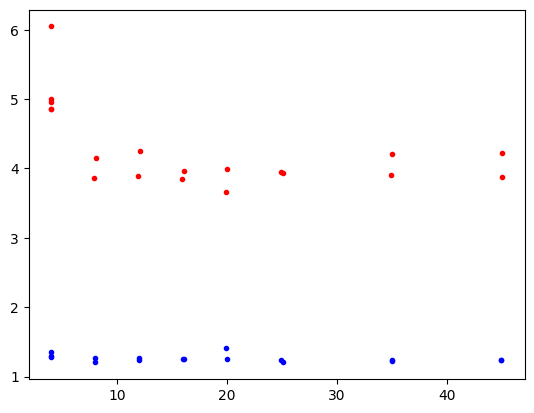

In [23]:
plt.plot(df_9['power (mW)'], 100*df_9['σ Density g/cm3']/df_9['Density g/cm3'], '.r')
plt.plot(df_16['power (mW)'], 100*df_16['σ Density g/cm3']/df_16['Density g/cm3'], '.b')

[]

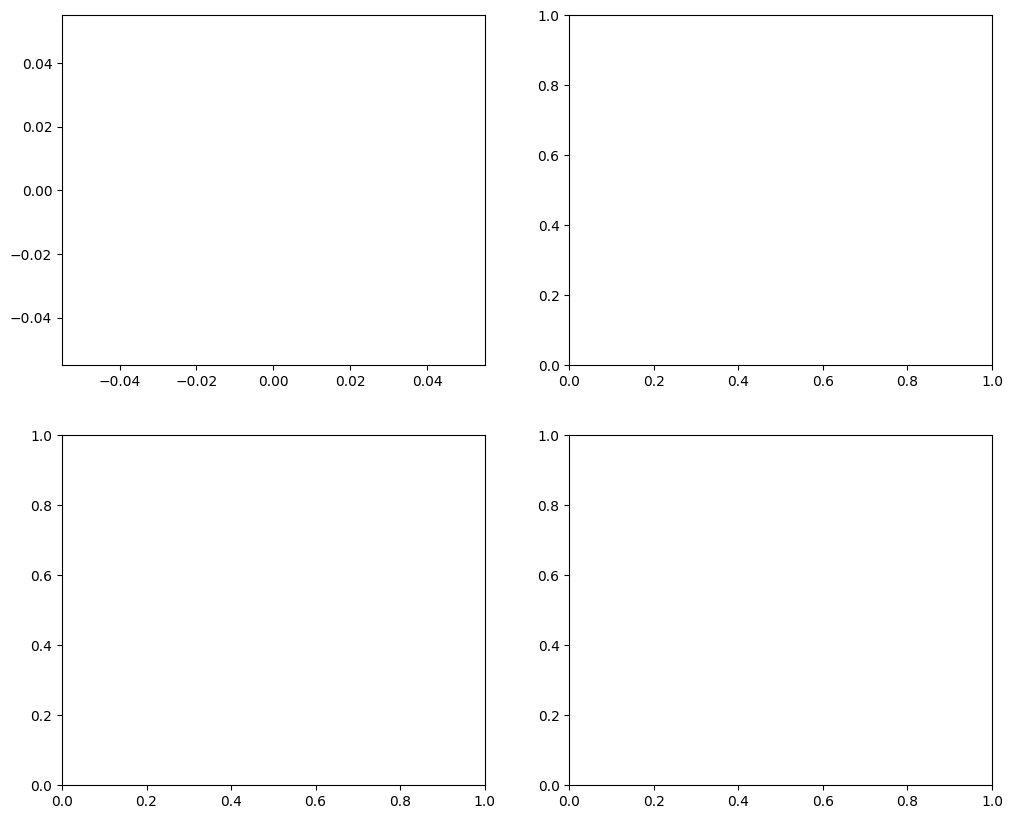

In [24]:
fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(2,2, figsize = (12,10))

ax0.plot()